# L2. Store and Recall

Store personal notes as vectors in **Qdrant Edge**, an embedded engine with no server and no network. One question, asked four times, walks a memory's whole life: recalled by meaning, forgotten on purpose, and persisted across a restart.

## 1. Ask before there's anything to remember

The model is already on the device. Watch what happens when we ask it something before storing a single memory.

In [1]:
from qdrant_edge import (
    EdgeShard, EdgeConfig, EdgeVectorParams, Distance,
    Query, QueryRequest,
)
from helper import fresh_start

SHARD_DIR = fresh_start("./coffee_shard")

config = EdgeConfig(
    vectors={
        "text": EdgeVectorParams(size=768, distance=Distance.Cosine),
    }
)
shard = EdgeShard.create(SHARD_DIR, config)
print("Empty shard created at", SHARD_DIR)

Empty shard created at ./coffee_shard


In [2]:
from helper import embed_query

question = "where can I sit outside for a latte?"
hits = shard.query(
    QueryRequest(
        query=Query.Nearest(embed_query(question), using="text"),
        limit=3,
        with_payload=True,
    )
)
print("Q:", question)
print("Memories found:", len(hits))

Q: where can I sit outside for a latte?
Memories found: 0


## 2. The memories

In [3]:
import json

memories = json.load(open("../data/memories.json"))
notes = [m for m in memories if m["source_type"] == "text"]
for m in notes[:6]:
    print(f"[{m['category']:>8}] {m['note']}")
print("...")
print(len(notes), "text notes")

[    food] Great little coffee place on 5th with outdoor seating and fast wifi
[    work] Standup with Sarah moved to Thursday to review the Q3 roadmap
[ errands] Pick up dry cleaning before Friday, ticket is on the fridge
[    work] Idea: batch the weekly report so it drafts itself every Monday
[  social] Mum's new address is 14 Elm Court, buzzer 3
[shopping] Liked the black and white running shoes at the mall, about $45
...
20 text notes


## 3. Turn notes into vectors, on the device

In [4]:
from helper import embed_text

vectors = embed_text([m["note"] for m in notes])
print(f"Embedded {len(vectors)} notes with Nomic (768 dimensions)")

Embedded 20 notes with Nomic (768 dimensions)


## 4. Store the memories

In [5]:
from qdrant_edge import Point, UpdateOperation

points = [
    Point(id=m["id"], vector={"text": vectors[i]}, payload=m)
    for i, m in enumerate(notes)
]
shard.update(UpdateOperation.upsert_points(points))
shard.optimize()
print("Stored", shard.info().points_count, "memories")

Stored 20 memories


## 5. The payoff: ask again — now it remembers

In [6]:
keyword = "latte"
matches = [m["note"] for m in notes if keyword in m["note"].lower()]
print(f'Notes containing "{keyword}":', len(matches))

Notes containing "latte": 0


In [7]:
hits = shard.query(
    QueryRequest(
        query=Query.Nearest(embed_query(question), using="text"),
        limit=3,
        with_payload=True,
    )
)
print("Q:", question, "\n")
for h in hits:
    print(f"  {h.score:.3f}  {h.payload['note']}")

Q: where can I sit outside for a latte? 

  0.653  Great little coffee place on 5th with outdoor seating and fast wifi
  0.590  Found a quiet cafe with good wifi to work from near the park
  0.511  Coffee run to the espresso bar near the office


## 6. The payoff: recall with the network off

In [8]:
from helper import no_network

offline_question = "when is the standup with Sarah?"
with no_network():
    offline_hits = shard.query(
        QueryRequest(
            query=Query.Nearest(embed_query(offline_question), using="text"),
            limit=1,
            with_payload=True,
        )
    )
print("Recall succeeded offline ->", offline_hits[0].payload["note"])

Recall succeeded offline -> Standup with Sarah moved to Thursday to review the Q3 roadmap


## 7. The payoff: how fast is local recall?

In [9]:
import time
from helper import add_filler

add_filler(shard, "text", 5000, 768)
n = shard.info().points_count

query_vector = embed_query("coffee")
timings = []
for _ in range(200):
    t0 = time.perf_counter()
    shard.query(
        QueryRequest(
            query=Query.Nearest(query_vector, using="text"),
            limit=3,
            with_payload=True,
        )
    )
    timings.append((time.perf_counter() - t0) * 1000)
timings.sort()
median_ms = timings[len(timings) // 2]
print(f"Local recall median at {n:,} memories: {median_ms:.2f} ms "
      f"over 200 queries, on this CPU-only sandbox")

Local recall median at 5,020 memories: 0.20 ms over 200 queries, on this CPU-only sandbox


## 8. The payoff: forget a memory

In [10]:
top = hits[0]
shard.update(UpdateOperation.delete_points([top.id]))
shard.optimize()
print("Forgot:", top.payload["note"])

Forgot: Great little coffee place on 5th with outdoor seating and fast wifi


In [11]:
from helper import before_after

hits_after = shard.query(
    QueryRequest(
        query=Query.Nearest(embed_query(question), using="text"),
        limit=3,
        with_payload=True,
    )
)
before_after(question,
             "Before forgetting",
             [f"{h.score:.3f}  {h.payload['note']}" for h in hits],
             "After forgetting",
             [f"{h.score:.3f}  {h.payload['note']}" for h in hits_after])

query: "where can I sit outside for a latte?"
✗ dropped by the filter · ✓ passed the filter

Before forgetting:
  ✗ 0.653  Great little coffee place on 5th with outdoor seating and fast wifi
    0.590  Found a quiet cafe with good wifi to work from near the park
    0.511  Coffee run to the espresso bar near the office

After forgetting:
  ✓ 0.590  Found a quiet cafe with good wifi to work from near the park
  ✓ 0.511  Coffee run to the espresso bar near the office
  ✓ 0.457  New bakery on the corner does an amazing morning cronut


## 9. The payoff: memory survives a restart — including what you forgot

   edge_config.json
   segments/bcce4420-996c-4fdd-8393-075a624851ce/id_tracker.deleted
   segments/bcce4420-996c-4fdd-8393-075a624851ce/id_tracker.mappings
   segments/bcce4420-996c-4fdd-8393-075a624851ce/id_tracker.versions
   segments/bcce4420-996c-4fdd-8393-075a624851ce/payload_index/config.json
34 plain files: the memory store, no process attached


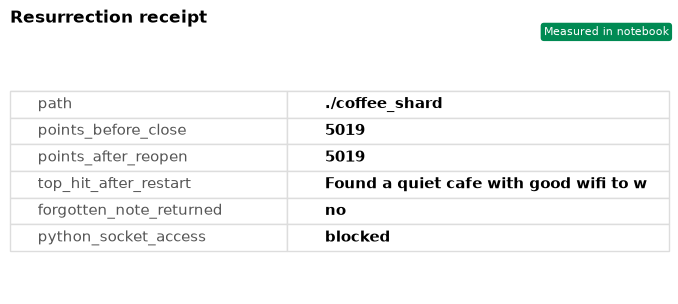

In [12]:
from pathlib import Path
from helper import receipt_table

before_count = shard.info().points_count
shard.close()

files = [p for p in Path(SHARD_DIR).rglob("*") if p.is_file()]
for p in sorted(files)[:5]:
    print("  ", p.relative_to(SHARD_DIR))
print(f"{len(files)} plain files: the memory store, no process attached")

with no_network():
    reloaded = EdgeShard.load(SHARD_DIR)
    final_hits = reloaded.query(
        QueryRequest(
            query=Query.Nearest(embed_query(question), using="text"),
            limit=3,
            with_payload=True,
        )
    )

receipt_table([
    ("path", SHARD_DIR),
    ("points_before_close", before_count),
    ("points_after_reopen", reloaded.info().points_count),
    ("top_hit_after_restart", final_hits[0].payload["note"][:38]),
    ("forgotten_note_returned",
     "no" if all(h.id != top.id for h in final_hits) else "yes"),
    ("python_socket_access", "blocked"),
])